In [8]:
import matplotlib.pyplot as plt


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import os

BASE = '/content/drive/MyDrive/opinionx'
print("Setup done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done


In [2]:
# Load processed data
df = pd.read_csv(f'{BASE}/data/sample/sample_5k.csv')

# Load saved models
tfidf = pickle.load(open(f'{BASE}/outputs/models/tfidf_vectorizer.pkl', 'rb'))
lr    = pickle.load(open(f'{BASE}/outputs/models/logistic_regression.pkl', 'rb'))
svm   = pickle.load(open(f'{BASE}/outputs/models/linear_svm.pkl', 'rb'))

print(f"Data loaded: {len(df):,} reviews")
print("Models loaded: TF-IDF, LR, SVM")

Data loaded: 5,000 reviews
Models loaded: TF-IDF, LR, SVM


In [3]:
# Load RAW processed data (has original review_body, ratings, votes)
df_raw = pd.read_csv(f'{BASE}/data/processed/reviews_clean.csv')

print(f"Loaded raw: {len(df_raw):,} reviews")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nSample trust-relevant fields:")
print(df_raw[['star_rating','helpful_votes','total_votes',
              'verified_purchase','review_length']].describe())

Loaded raw: 74,938 reviews
Columns: ['star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'product_title', 'product_category', 'sentiment', 'label', 'review_length', 'helpfulness_ratio', 'clean_text', 'clean_headline', 'full_text']

Sample trust-relevant fields:
        star_rating  helpful_votes   total_votes  review_length
count  74938.000000   74938.000000  74938.000000   74938.000000
mean       4.078198       0.925151      1.193787      48.832235
std        1.461937      14.581912     15.706997     101.194687
min        1.000000       0.000000      0.000000       1.000000
25%        4.000000       0.000000      0.000000      11.000000
50%        5.000000       0.000000      0.000000      23.000000
75%        5.000000       0.000000      1.000000      52.000000
max        5.000000    2506.000000   2720.000000    7501.000000


In [4]:
def compute_trust_score(row) -> float:
    score = 1.0

    # Use original review body not cleaned text
    text = str(row.get('review_body', ''))
    words = text.split()

    # 1. Length — penalize very short reviews
    if len(words) < 5:
        score -= 0.35
    elif len(words) < 15:
        score -= 0.15
    elif len(words) > 300:
        score -= 0.05  # suspiciously long

    # 2. Verified purchase
    if str(row.get('verified_purchase', '')).upper() == 'Y':
        score += 0.10
    else:
        score -= 0.10  # unverified = slight penalty

    # 3. Helpfulness ratio
    helpful = float(row.get('helpful_votes', 0) or 0)
    total   = float(row.get('total_votes',   0) or 0)
    if total >= 5:
        ratio = helpful / total
        if ratio >= 0.8:   score += 0.15
        elif ratio >= 0.5: score += 0.05
        elif ratio < 0.2:  score -= 0.15
    elif total > 0:
        score += 0.02  # some votes but not enough to judge

    # 4. ALL CAPS abuse
    if len(text) > 0:
        caps_ratio = sum(1 for c in text if c.isupper()) / len(text)
        if caps_ratio > 0.6:   score -= 0.25
        elif caps_ratio > 0.4: score -= 0.10

    # 5. Repetition — low unique word ratio
    if len(words) > 0:
        unique_ratio = len(set(words)) / len(words)
        if unique_ratio < 0.3:   score -= 0.20
        elif unique_ratio < 0.5: score -= 0.10

    # 6. Excessive punctuation
    if text.count('!') > 5:  score -= 0.10
    if text.count('?') > 5:  score -= 0.05

    # 7. Rating-sentiment mismatch
    rating    = float(row.get('star_rating', 0) or 0)
    sentiment = str(row.get('sentiment', ''))
    if rating >= 4 and sentiment == 'negative': score -= 0.25
    if rating <= 2 and sentiment == 'positive': score -= 0.25

    # 8. Generic spam phrases
    text_lower = text.lower()
    spam_phrases = [
        'five stars', 'great product', 'love it',
        'highly recommend', 'works great', 'as described'
    ]
    spam_count = sum(1 for p in spam_phrases if p in text_lower)
    if spam_count >= 2 and len(words) < 20:
        score -= 0.20

    return round(max(0.0, min(1.0, score)), 2)

# Apply to raw data
df_raw['trust_score'] = df_raw.apply(compute_trust_score, axis=1)

print("Trust score distribution:")
print(df_raw['trust_score'].describe().round(3))
print(f"\nValue counts (rounded):")
print(df_raw['trust_score'].round(1).value_counts().sort_index())

Trust score distribution:
count    74938.000
mean         0.971
std          0.047
min          0.500
25%          0.950
50%          1.000
75%          1.000
max          1.000
Name: trust_score, dtype: float64

Value counts (rounded):
trust_score
0.5       13
0.6       46
0.7      264
0.8     1690
0.9     5445
1.0    67480
Name: count, dtype: int64


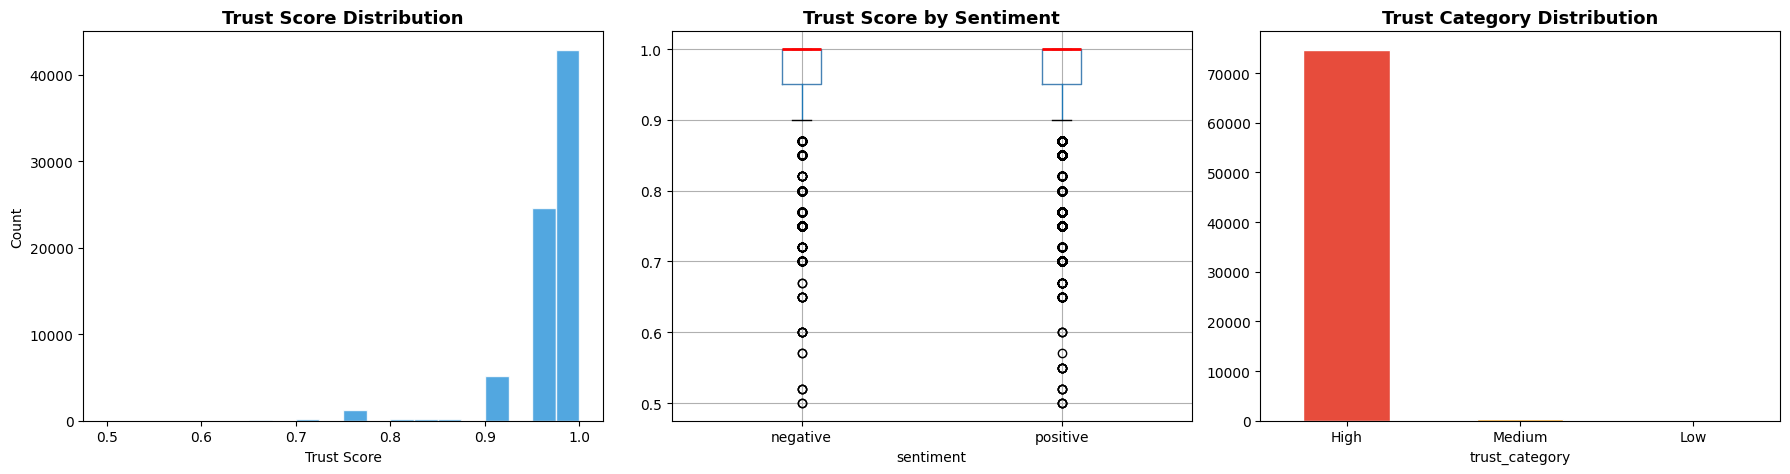

Saved: 74,938 reviews with trust scores


In [9]:
# In Cell 4, replace df with df_raw everywhere
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_raw['trust_score'], bins=20,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Trust Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trust Score')
axes[0].set_ylabel('Count')

df_raw.boxplot(column='trust_score', by='sentiment', ax=axes[1],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Trust Score by Sentiment',
                  fontsize=13, fontweight='bold')
plt.suptitle('')

bins   = [0, 0.4, 0.7, 1.01]
labels = ['Low', 'Medium', 'High']
df_raw['trust_category'] = pd.cut(df_raw['trust_score'],
                                   bins=bins, labels=labels)
df_raw['trust_category'].value_counts().plot(
    kind='bar', ax=axes[2],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
axes[2].set_title('Trust Category Distribution',
                  fontsize=13, fontweight='bold')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/11_trust_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save with trust scores
df_raw.to_csv(f'{BASE}/data/processed/reviews_with_trust.csv', index=False)
print(f"Saved: {len(df_raw):,} reviews with trust scores")

In [11]:
def predict_review(text: str, model_name: str = 'svm') -> dict:
    """
    Takes raw review text, returns sentiment + trust score.
    This is the function the Streamlit dashboard will call.
    """
    import re, string

    # Clean text
    text_clean = text.lower()
    text_clean = re.sub(r'<.*?>', ' ', text_clean)
    text_clean = re.sub(r'http\S+', ' ', text_clean)
    text_clean = text_clean.translate(
        str.maketrans('', '', string.punctuation))
    text_clean = re.sub(r'\d+', ' ', text_clean)
    text_clean = re.sub(r'\s+', ' ', text_clean).strip()

    # Vectorize
    vec = tfidf.transform([text_clean])

    # Predict
    if model_name == 'svm':
        pred = svm.predict(vec)[0]
        # SVM decision score as confidence proxy
        score = svm.decision_function(vec)[0]
        confidence = min(abs(score) / 3, 1.0)
    else:
        pred = lr.predict(vec)[0]
        proba = lr.predict_proba(vec)[0]
        confidence = float(max(proba))

    # Trust score from text signals only
    words = text.split()
    trust = 1.0
    if len(words) < 5:   trust -= 0.30
    if len(words) < 15:  trust -= 0.10
    caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    if caps_ratio > 0.5: trust -= 0.20
    unique_ratio = len(set(words)) / max(len(words), 1)
    if unique_ratio < 0.4: trust -= 0.15
    if text.count('!') > 5: trust -= 0.10
    trust = round(max(0.0, min(1.0, trust)), 2)

    return {
        'sentiment':  'Positive' if pred == 1 else 'Negative',
        'label':      int(pred),
        'confidence': round(float(confidence), 3),
        'trust_score': trust,
        'clean_text': text_clean,
        'word_count': len(words)
    }

# Test it
test_review = "This product is absolutely amazing! Works perfectly and arrived fast."
result = predict_review(test_review)
print("Test prediction:")
for k, v in result.items():
    print(f"  {k}: {v}")

Test prediction:
  sentiment: Positive
  label: 1
  confidence: 0.757
  trust_score: 0.9
  clean_text: this product is absolutely amazing works perfectly and arrived fast
  word_count: 10


In [12]:
# Save dataset with trust scores
df.to_csv(f'{BASE}/data/processed/reviews_with_trust.csv', index=False)
print(f"Saved with trust scores: {len(df):,} reviews")

# Save predictor function as a module
predictor_code = '''
import re, string, pickle

def load_models(base_path):
    tfidf = pickle.load(open(f"{base_path}/tfidf_vectorizer.pkl", "rb"))
    lr    = pickle.load(open(f"{base_path}/logistic_regression.pkl", "rb"))
    svm   = pickle.load(open(f"{base_path}/linear_svm.pkl",          "rb"))
    return tfidf, lr, svm

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\\d+", " ", text)
    return re.sub(r"\\s+", " ", text).strip()

def trust_score(text):
    words = text.split()
    score = 1.0
    if len(words) < 5:   score -= 0.30
    if len(words) < 15:  score -= 0.10
    caps = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    if caps > 0.5:       score -= 0.20
    uniq = len(set(words)) / max(len(words), 1)
    if uniq < 0.4:       score -= 0.15
    if text.count("!") > 5: score -= 0.10
    return round(max(0.0, min(1.0, score)), 2)

def predict(text, tfidf, svm, lr, model_name="svm"):
    clean = clean_text(text)
    vec   = tfidf.transform([clean])
    if model_name == "svm":
        pred       = svm.predict(vec)[0]
        conf_score = svm.decision_function(vec)[0]
        confidence = min(abs(conf_score) / 3, 1.0)
    else:
        pred       = lr.predict(vec)[0]
        confidence = float(max(lr.predict_proba(vec)[0]))
    return {
        "sentiment":   "Positive" if pred == 1 else "Negative",
        "label":       int(pred),
        "confidence":  round(confidence, 3),
        "trust_score": trust_score(text),
        "word_count":  len(text.split())
    }
'''

with open(f'{BASE}/src/predictor.py', 'w') as f:
    f.write(predictor_code)

print("Predictor module saved to src/predictor.py")

Saved with trust scores: 5,000 reviews
Predictor module saved to src/predictor.py
